# 05 — Heat Days: TX90p (xclim calendar-day percentile)

Replicates the analysis in `03_threshold_analysis` but replaces the flat
per-pixel percentile baseline with **ETCCDI-style calendar-day percentile
thresholds** computed by `xclim`, using a centred 5-day moving window.
Three relative thresholds are compared: P90, P95, and P99.

**Prerequisites:** run `01_data_acquisition` then `02_compute_baselines` first.

## Methodological difference from notebook 03

Notebook 03 computes a **flat percentile baseline**: for each pixel, a single
percentile value is derived by pooling *all* daily Tmax values across the
entire 2003–2020 record. A day is flagged as a heat day if that pixel's Tmax
exceeds this fixed scalar threshold — regardless of the time of year.

This notebook uses **calendar-day percentile thresholds**: for each of the
365 days of the year, the percentile is estimated from values within a centred
**5-day moving window** (i.e. ±2 days around that calendar day, pooled across
all years in the reference period). A day is flagged when observed Tmax exceeds
the threshold for *that specific day of the year*.

The calendar-day approach removes the annual cycle before defining extremes,
so a warm winter day and a warm summer day are each judged against their own
seasonal norm — more physically meaningful than a single annual percentile.
The P90 result is equivalent to the ETCCDI TX90p index.

## Setup

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr

sys.path.insert(0, os.path.dirname(os.path.abspath('__file__')))
from utils.heat import (
    CITIES,
    load_city,
    load_tx90p_threshold,
    compute_absolute_heat_days,
    load_neighbourhood_boundaries,
    aggregate_to_neighbourhoods,
    plot_quadrant,
)

In [2]:
DATA_DIR          = 'data'
YEAR              = 2020          # representative year for spatial maps
ABS_THRESHOLD     = 30.0          # absolute Tmax threshold in °C
TX90P_PERCENTILES = [90, 95, 99]  # relative thresholds to compare
CITY_KEYS         = ['salvador', 'teresina', 'caceres']

COLOURS = {
    f'Abs ≥{ABS_THRESHOLD:.0f} °C': '#333333',
    'P90': '#e07b39',
    'P95': '#c0392b',
    'P99': '#7b0e0e',
}

cities = {}
for c in CITY_KEYS:
    da = load_city(c, DATA_DIR)
    da.attrs['units'] = 'degC'
    cities[c] = da

salvador: shape {'time': 6497, 'lat': 55, 'lon': 67}  2003-01-01 to 2020-12-30
teresina: shape {'time': 6497, 'lat': 67, 'lon': 78}  2003-01-01 to 2020-12-30
caceres: shape {'time': 6497, 'lat': 89, 'lon': 89}  2003-01-01 to 2020-12-30


## Calendar-day percentile thresholds

Loads thresholds precomputed in `02_compute_baselines.ipynb`.
Shape is `(percentile, dayofyear, lat, lon)` — one threshold value per
pixel per day of year per percentile level.

In [3]:
thresholds = {c: load_tx90p_threshold(c, DATA_DIR) for c in CITY_KEYS}

salvador TX90p threshold: shape {'percentile': 3, 'lat': 55, 'lon': 67, 'dayofyear': 365}  window=5  percentiles=[90, 95, 99]  range 26.0–88.4 °C
teresina TX90p threshold: shape {'percentile': 3, 'lat': 67, 'lon': 78, 'dayofyear': 365}  window=5  percentiles=[90, 95, 99]  range 32.7–65.9 °C
caceres TX90p threshold: shape {'percentile': 3, 'lat': 89, 'lon': 89, 'dayofyear': 365}  window=5  percentiles=[90, 95, 99]  range 30.9–52.7 °C


### Seasonality of the calendar-day thresholds

City-wide mean threshold by day of year — confirms the 5-day window
produces genuine seasonal variation rather than a flat scalar.

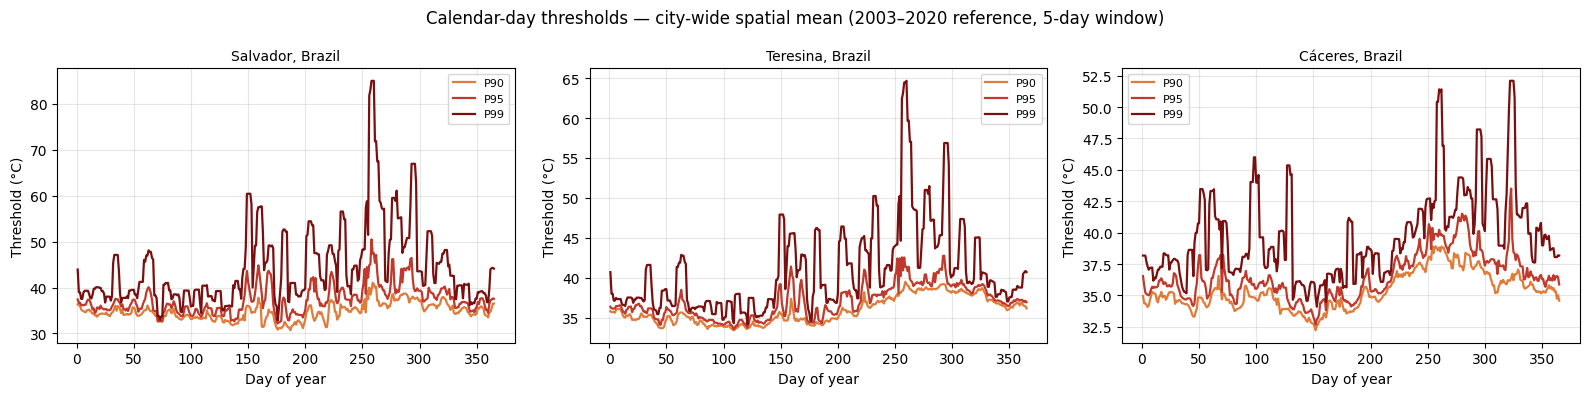

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=False)

pct_colours = {'P90': '#e07b39', 'P95': '#c0392b', 'P99': '#7b0e0e'}

for ax, c in zip(axes, CITY_KEYS):
    for p in TX90P_PERCENTILES:
        thr_mean = thresholds[c].sel(percentile=p).mean(dim=['lat', 'lon'])
        ax.plot(thr_mean.dayofyear.values, thr_mean.values,
                linewidth=1.6, color=pct_colours[f'P{p}'], label=f'P{p}')
    ax.set_title(CITIES[c]['label'], fontsize=10)
    ax.set_xlabel('Day of year')
    ax.set_ylabel('Threshold (°C)')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

fig.suptitle('Calendar-day thresholds — city-wide spatial mean (2003–2020 reference, 5-day window)',
             fontsize=12)
plt.tight_layout()
plt.show()

## Annual heat day counts

For each city and percentile level, count the number of days per year where
Tmax exceeds the calendar-day threshold for that day of year.

In [5]:
def count_doy_exceedances(da, thresh_doy):
    """Annual count of days where da > calendar-day threshold thresh_doy."""
    thresh_aligned = thresh_doy.sel(dayofyear=da.time.dt.dayofyear)
    return (da > thresh_aligned).resample(time='YS').sum(dim='time')


# tx_annual[city][percentile] -> DataArray (time, lat, lon)
tx_annual = {c: {} for c in CITY_KEYS}
for c in CITY_KEYS:
    for p in TX90P_PERCENTILES:
        result = count_doy_exceedances(cities[c], thresholds[c].sel(percentile=p))
        tx_annual[c][p] = result
        mean_days = float(result.mean(dim=['lat', 'lon']).mean())
        print(f'{c}  P{p}: city-wide mean {mean_days:.1f} days/year')

salvador  P90: city-wide mean 11.1 days/year
salvador  P95: city-wide mean 4.9 days/year
salvador  P99: city-wide mean 1.1 days/year
teresina  P90: city-wide mean 33.7 days/year
teresina  P95: city-wide mean 15.0 days/year
teresina  P99: city-wide mean 3.8 days/year
caceres  P90: city-wide mean 34.2 days/year
caceres  P95: city-wide mean 15.5 days/year
caceres  P99: city-wide mean 3.6 days/year


## Threshold sensitivity

How many heat days per year does each city accumulate under the absolute
threshold and the three calendar-day relative thresholds?  The right panel
maps each percentile level to the corresponding annual-mean threshold
temperature so you can read off what P90 means in real °C for each city.

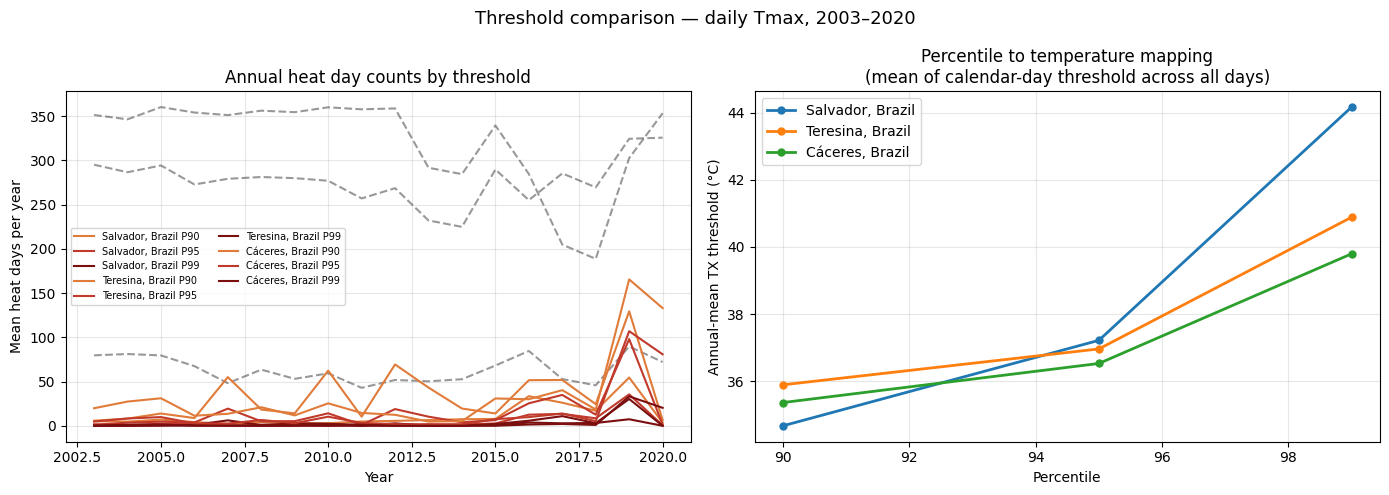

In [6]:
ALL_YEARS = list(range(2003, 2021))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: city-wide mean heat days per year under each threshold
for c in CITY_KEYS:
    label = CITIES[c]['label']
    abs_counts = [
        float((cities[c].sel(time=cities[c].time.dt.year == yr) >= ABS_THRESHOLD)
              .sum(dim='time').mean())
        for yr in ALL_YEARS
    ]
    axes[0].plot(ALL_YEARS, abs_counts, linestyle='--', linewidth=1.5,
                 color=COLOURS[f'Abs ≥{ABS_THRESHOLD:.0f} °C'], alpha=0.5)

    for p in TX90P_PERCENTILES:
        tx_counts = [
            float(tx_annual[c][p].isel(time=(tx_annual[c][p].time.dt.year == yr)).squeeze().mean())
            for yr in ALL_YEARS
        ]
        axes[0].plot(ALL_YEARS, tx_counts, linewidth=1.5,
                     color=pct_colours[f'P{p}'],
                     label=f'{label} P{p}')

axes[0].set_xlabel('Year')
axes[0].set_ylabel('Mean heat days per year')
axes[0].set_title('Annual heat day counts by threshold')
axes[0].legend(fontsize=7, ncol=2)
axes[0].grid(True, alpha=0.3)

# Right: percentile → annual-mean threshold temperature
for c in CITY_KEYS:
    vals = [float(thresholds[c].sel(percentile=p).mean()) for p in TX90P_PERCENTILES]
    axes[1].plot(TX90P_PERCENTILES, vals, marker='o', linewidth=2,
                 markersize=5, label=CITIES[c]['label'])

axes[1].set_xlabel('Percentile')
axes[1].set_ylabel('Annual-mean TX threshold (°C)')
axes[1].set_title('Percentile to temperature mapping\n(mean of calendar-day threshold across all days)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

fig.suptitle('Threshold comparison — daily Tmax, 2003–2020', fontsize=13)
plt.tight_layout()
plt.show()

## Distribution of daily Tmax

Histogram of city-wide daily mean Tmax (2003–2020) with vertical lines
marking the absolute threshold and the annual-mean calendar-day threshold
at each percentile level.  Because the calendar-day threshold varies by day
of year, the vline shows its year-round average — the actual threshold on any
given day will be higher (summer) or lower (winter) than this value.

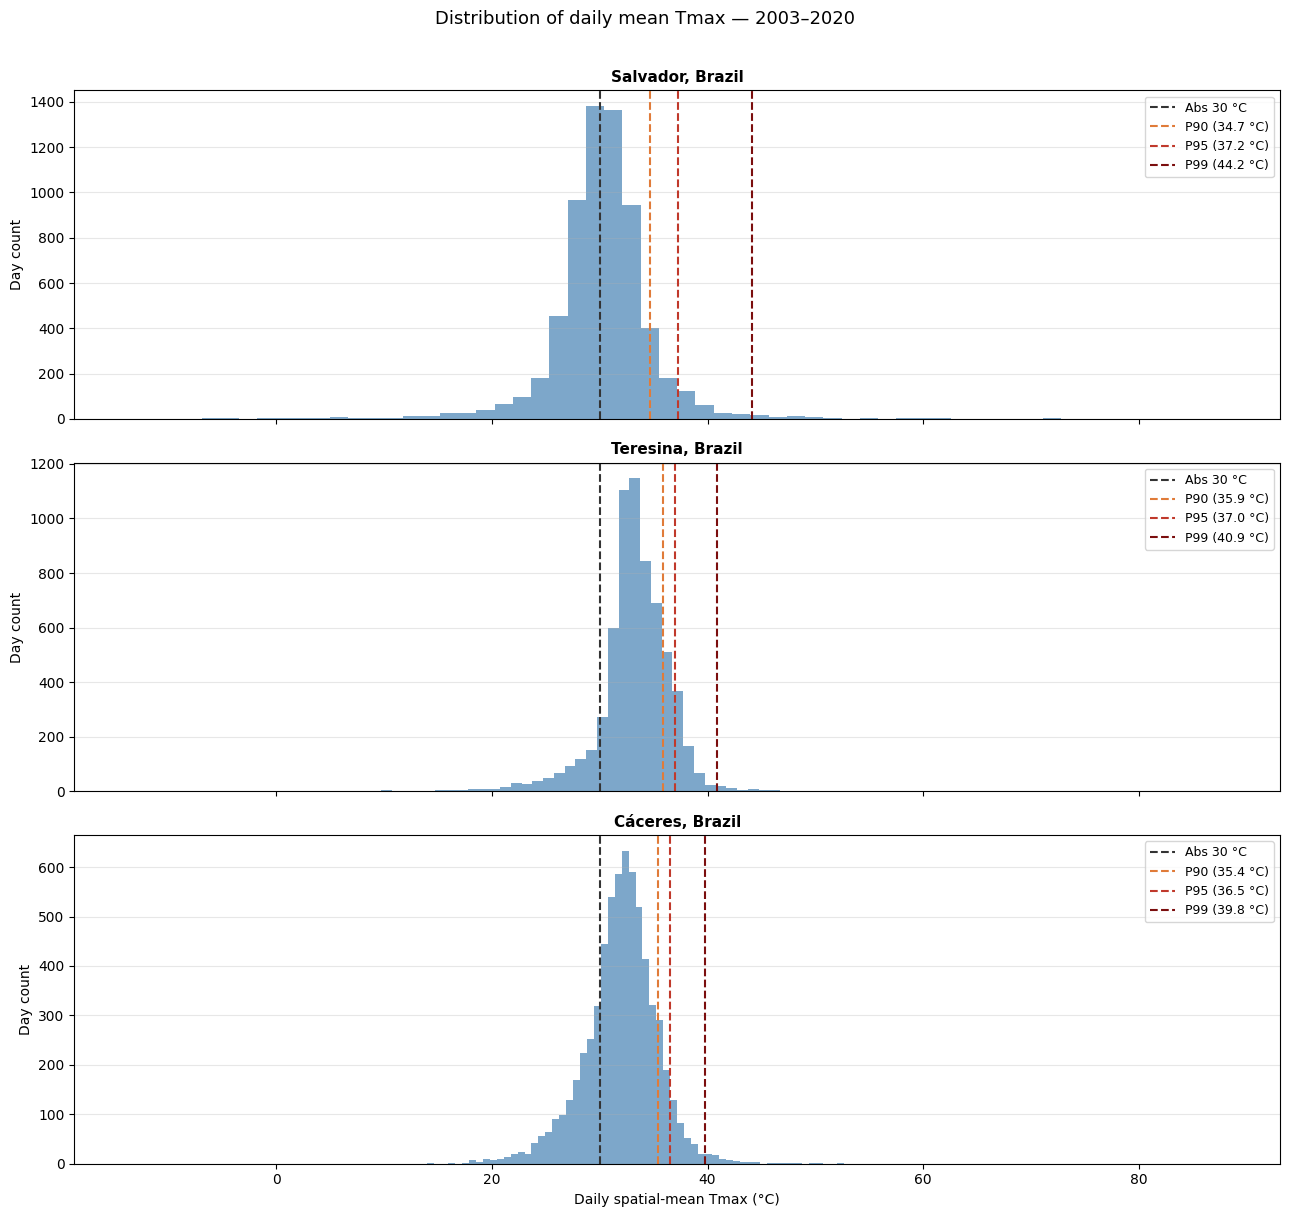

In [7]:
fig, axes = plt.subplots(3, 1, figsize=(13, 12), sharex=True, sharey=False)

for ax, c in zip(axes, CITY_KEYS):
    label      = CITIES[c]['label']
    daily_mean = cities[c].mean(dim=['lat', 'lon']).values

    ax.hist(daily_mean, bins=60, color='steelblue', alpha=0.7, edgecolor='none')

    vlines = {
        f'Abs {ABS_THRESHOLD:.0f} °C': (ABS_THRESHOLD, COLOURS[f'Abs ≥{ABS_THRESHOLD:.0f} °C']),
    }
    for p in TX90P_PERCENTILES:
        mean_thr = float(thresholds[c].sel(percentile=p).mean())
        vlines[f'P{p} ({mean_thr:.1f} °C)'] = (mean_thr, pct_colours[f'P{p}'])

    for vlabel, (xval, colour) in vlines.items():
        ax.axvline(xval, color=colour, linestyle='--', linewidth=1.5, label=vlabel)

    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.set_ylabel('Day count')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3, axis='y')

axes[-1].set_xlabel('Daily spatial-mean Tmax (°C)')
fig.suptitle('Distribution of daily mean Tmax — 2003–2020', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## Spatial patterns

Side-by-side neighbourhood choropleth maps for each city comparing:

- **Absolute:** days where Tmax ≥ 30 °C
- **P90 calendar-day:** days where Tmax exceeds the seasonally calibrated
  90th-percentile threshold (the ETCCDI TX90p definition)

Neighbourhood boundaries are loaded from the geobr cache.

In [8]:
import matplotlib.cm as mcm
import matplotlib.patches as mpatches


def plot_abs_vs_tx90p(city_key, year, percentile=90):
    """Neighbourhood choropleth: absolute heat days vs calendar-day percentile heat days."""
    da    = cities[city_key]
    label = CITIES[city_key]['label']

    abs_map  = compute_absolute_heat_days(da, year, ABS_THRESHOLD)
    tx_yr    = (
        tx_annual[city_key][percentile]
        .isel(time=(tx_annual[city_key][percentile].time.dt.year == year))
        .squeeze('time')
    )

    gdf      = load_neighbourhood_boundaries(city_key, DATA_DIR)
    abs_nbhd = aggregate_to_neighbourhoods(abs_map, gdf)
    tx_nbhd  = aggregate_to_neighbourhoods(tx_yr,   gdf)

    cmap_obj = mcm.get_cmap('YlOrRd')
    fig, axes = plt.subplots(1, 2, figsize=(15, 7))
    panels = [
        (abs_nbhd, axes[0], f'Absolute: Tmax ≥ {ABS_THRESHOLD:.0f} °C  ({year})'),
        (tx_nbhd,  axes[1], f'P{percentile} calendar-day threshold, 5-day window  ({year})'),
    ]
    for nbhd_gdf, ax, title in panels:
        series  = nbhd_gdf['mean_heat_days']
        working = nbhd_gdf.copy()
        working['_rank'] = series.rank(pct=True, method='first', na_option='keep')
        working.plot(
            column='_rank', ax=ax, cmap='YlOrRd', vmin=0, vmax=1,
            edgecolor='black', linewidth=0.4, legend=False,
            missing_kwds={'color': 'lightgrey', 'edgecolor': 'black', 'linewidth': 0.4},
        )
        valid_idx     = working['_rank'].dropna().index
        ranked_series = series.loc[valid_idx].sort_values()
        n_valid       = len(ranked_series)
        handles = []
        for i in range(5):
            lo_i = int(i * n_valid / 5)
            hi_i = int((i + 1) * n_valid / 5)
            band = ranked_series.iloc[lo_i:hi_i]
            handles.append(mpatches.Patch(
                facecolor=cmap_obj((i * 2 + 1) / 10),
                label=f'{band.min():.1f}–{band.max():.1f} days',
            ))
        n_nan = series.isna().sum()
        if n_nan:
            handles.append(mpatches.Patch(facecolor='lightgrey', label=f'No data ({n_nan})'))
        ax.legend(handles=handles, title='Mean heat days\n(quintile rank)',
                  fontsize=7, title_fontsize=7, loc='lower left')
        for _, row in nbhd_gdf.iterrows():
            cx, cy = row.geometry.centroid.x, row.geometry.centroid.y
            ax.annotate(row['name'], xy=(cx, cy), ha='center', va='center',
                        fontsize=6.5, color='black',
                        bbox=dict(boxstyle='round,pad=0.1', fc='white', alpha=0.5, lw=0))
        ax.set_title(title, fontsize=10)
        ax.set_aspect('equal')

    fig.suptitle(f'Neighbourhood heat exposure — {label} {year}', fontsize=13)
    plt.tight_layout()
    plt.show()
    return abs_nbhd, tx_nbhd

### Salvador

Loaded 22 neighbourhoods from cache: data/geobr_salvador_neighbourhoods_2010.gpkg


/tmp/ipykernel_25432/127130421.py:21: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_obj = mcm.get_cmap('YlOrRd')


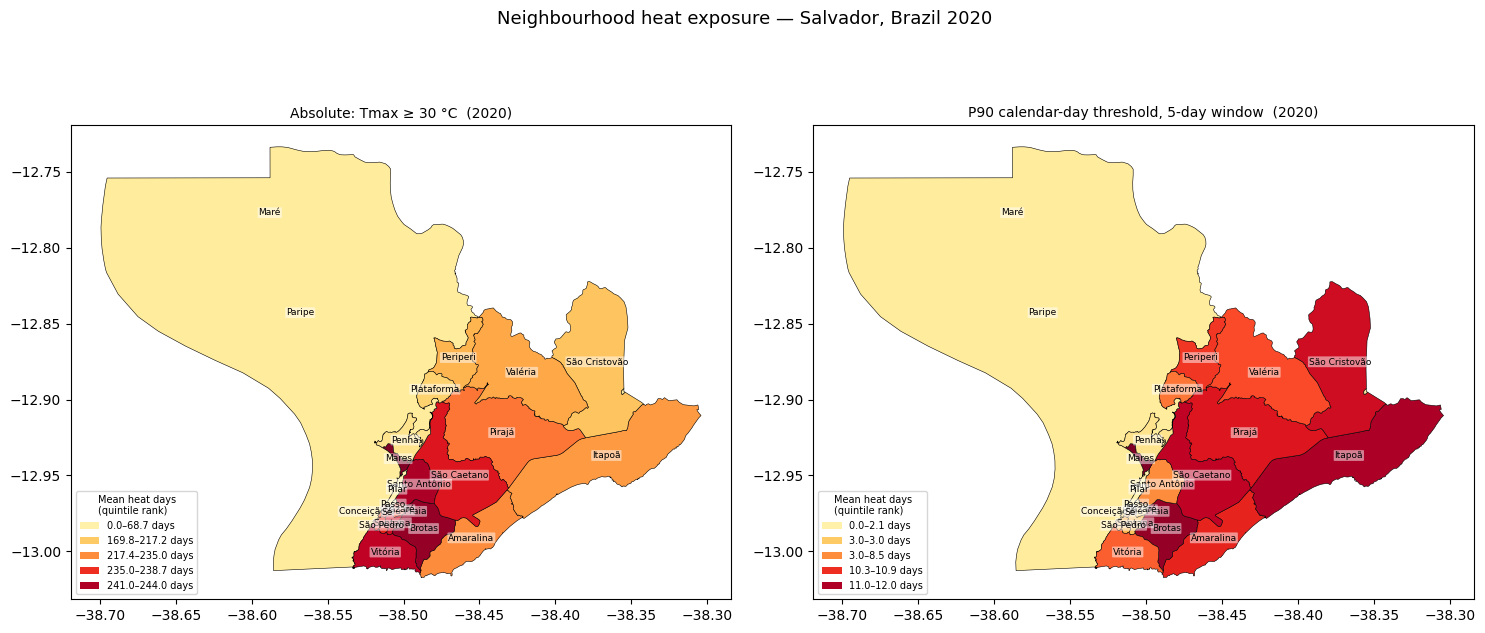

In [9]:
abs_sal, tx_sal = plot_abs_vs_tx90p('salvador', YEAR)

### Teresina

Loaded 112 neighbourhoods from cache: data/geobr_teresina_neighbourhoods_2010.gpkg


/tmp/ipykernel_25432/127130421.py:21: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_obj = mcm.get_cmap('YlOrRd')


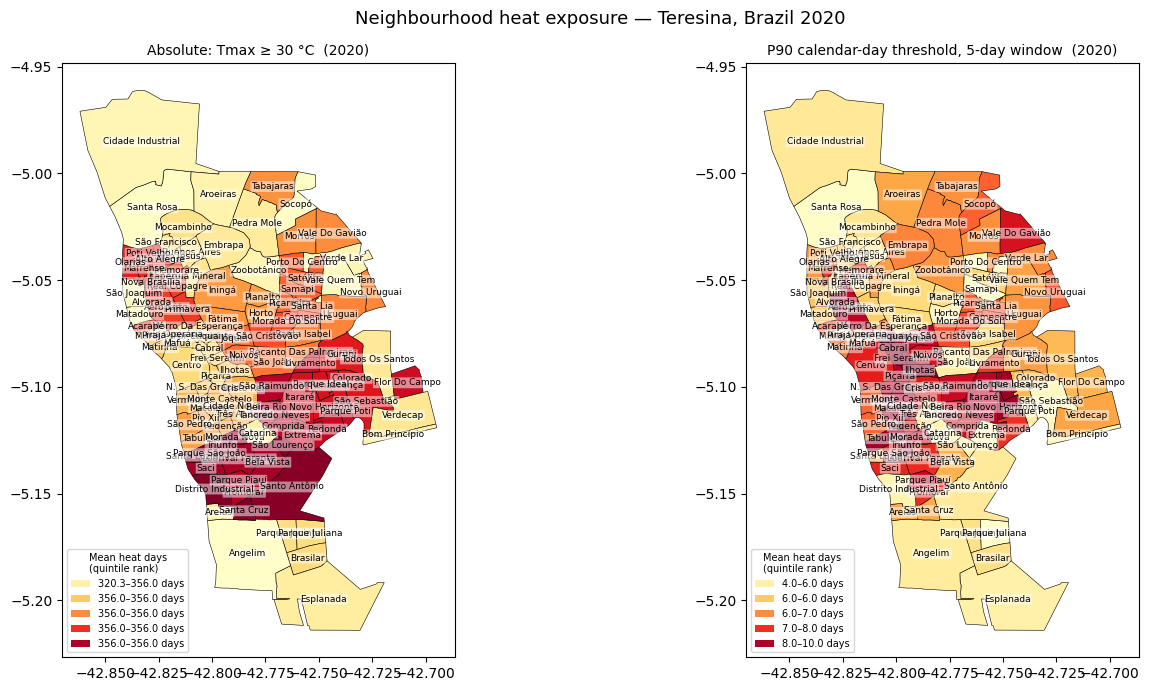

In [10]:
abs_ter, tx_ter = plot_abs_vs_tx90p('teresina', YEAR)

### Cáceres

Loaded 43 neighbourhoods from cache: data/geobr_caceres_neighbourhoods_2010.gpkg


/tmp/ipykernel_25432/127130421.py:21: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_obj = mcm.get_cmap('YlOrRd')


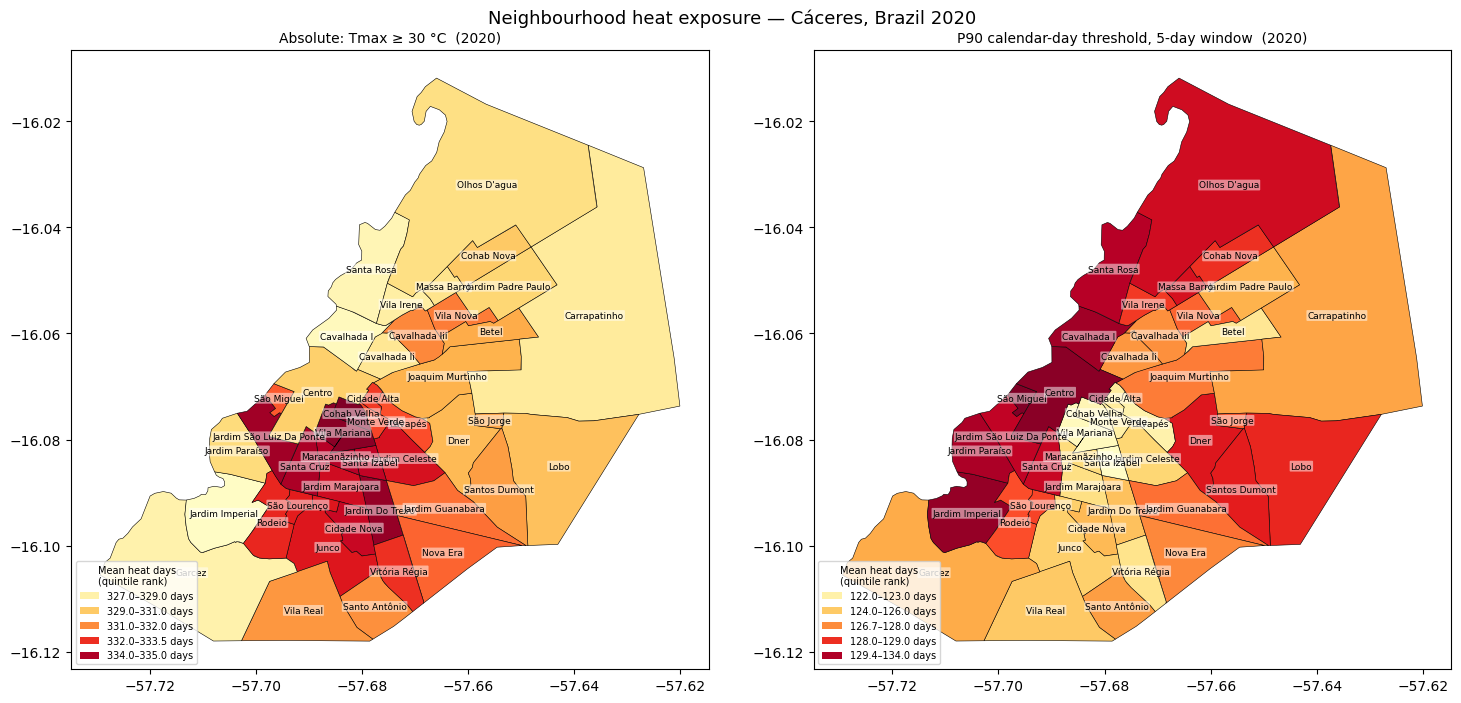

In [11]:
abs_cac, tx_cac = plot_abs_vs_tx90p('caceres', YEAR)

## Neighbourhood prioritisation

Rank each neighbourhood simultaneously on the absolute framing and the
P90 calendar-day framing.  Neighbourhoods in the top-right quadrant are
robust priorities under both methods.

Spearman rho quantifies ranking agreement; rho near 1 means the choice of
framing barely matters for prioritisation.

### Salvador

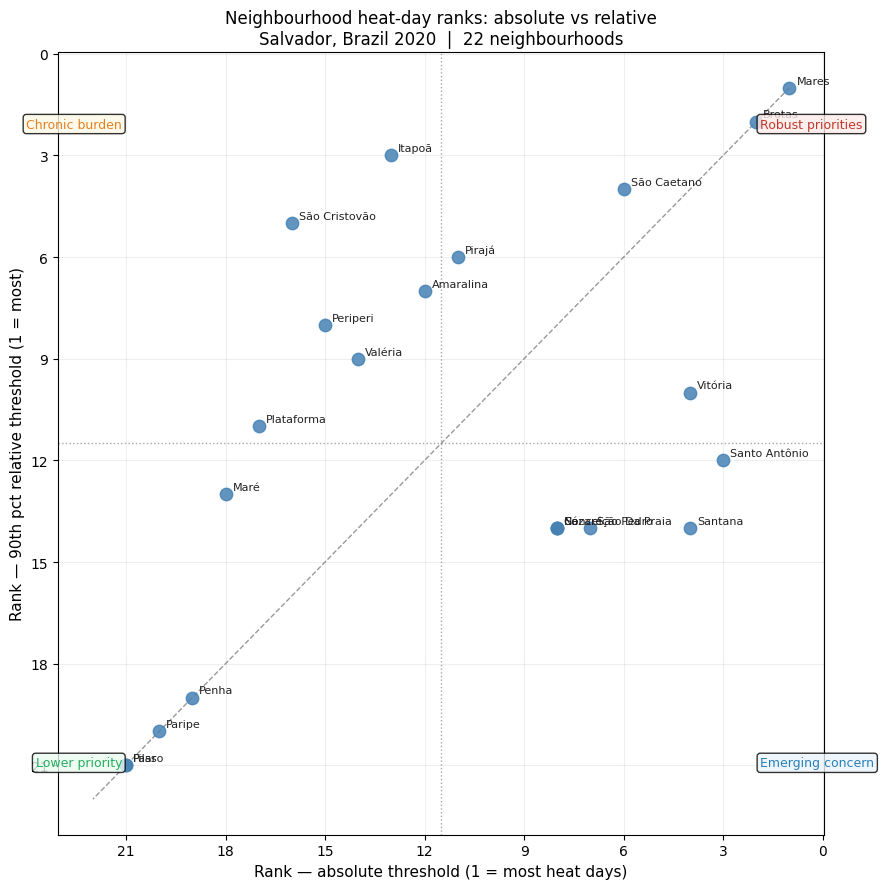

Spearman rho = 0.498  (p = 0.018,  n = 22)


In [12]:
plot_quadrant(abs_sal, tx_sal, YEAR, 90, CITIES['salvador']['label'])

### Teresina

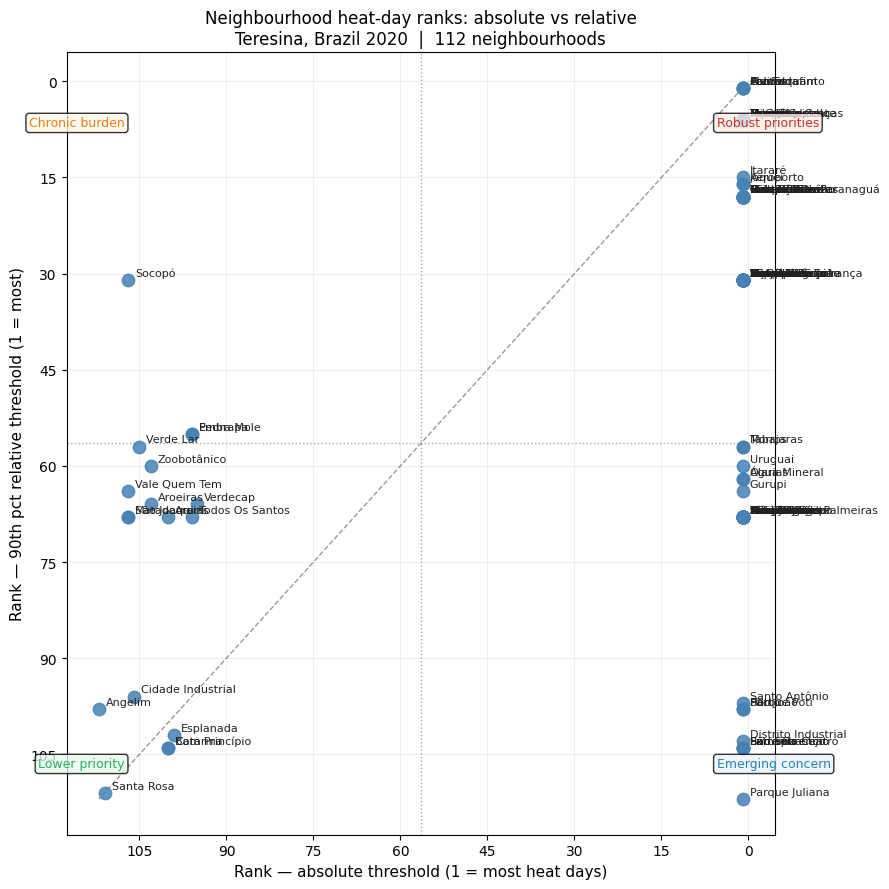

Spearman rho = 0.309  (p = <0.001,  n = 112)


In [13]:
plot_quadrant(abs_ter, tx_ter, YEAR, 90, CITIES['teresina']['label'])

### Cáceres

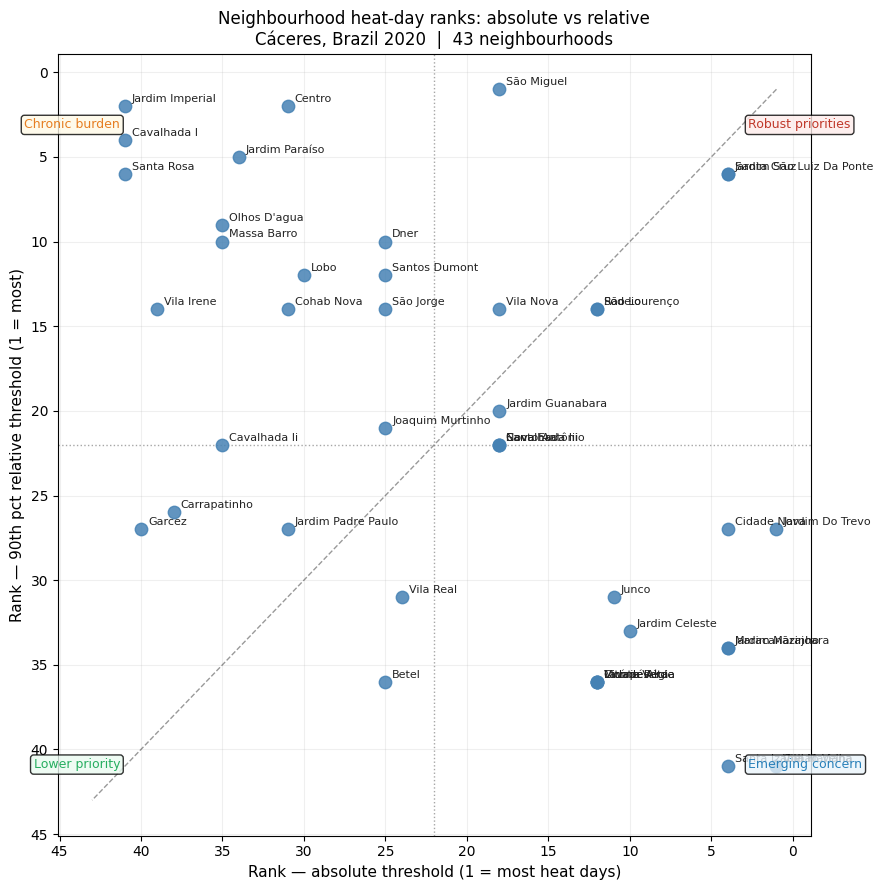

Spearman rho = -0.556  (p = <0.001,  n = 43)


In [14]:
plot_quadrant(abs_cac, tx_cac, YEAR, 90, CITIES['caceres']['label'])

## Threshold comparison summary

Average annual heat days per city (2003–2020) under the absolute threshold
and all three calendar-day relative thresholds.  A second table shows the
annual-mean threshold temperature for each percentile level — the calendar-day
equivalent of the percentile-to-temperature mapping in notebook 03.

In [15]:
count_rows = []
temp_rows  = []

for c in CITY_KEYS:
    label = CITIES[c]['label']

    abs_annual = [
        float((cities[c].sel(time=cities[c].time.dt.year == yr) >= ABS_THRESHOLD)
              .sum(dim='time').mean())
        for yr in ALL_YEARS
    ]
    count_row = {'City': label, f'Abs ≥{ABS_THRESHOLD:.0f} °C': float(np.mean(abs_annual))}
    temp_row  = {'City': label}

    for p in TX90P_PERCENTILES:
        tx_counts = [
            float(tx_annual[c][p].isel(time=(tx_annual[c][p].time.dt.year == yr)).squeeze().mean())
            for yr in ALL_YEARS
        ]
        count_row[f'P{p}'] = float(np.mean(tx_counts))
        temp_row[f'P{p} (°C)'] = float(thresholds[c].sel(percentile=p).mean())

    count_rows.append(count_row)
    temp_rows.append(temp_row)

counts = pd.DataFrame(count_rows).set_index('City')
temps  = pd.DataFrame(temp_rows).set_index('City')

table_styles = [
    {'selector': 'caption', 'props': 'font-size:1em; font-weight:bold; padding-bottom:8px;'},
    {'selector': 'th', 'props': 'text-align:center; white-space:nowrap;'},
    {'selector': 'td', 'props': 'text-align:center;'},
]

display(
    counts.style
    .format('{:.1f}')
    .background_gradient(cmap='YlOrRd', axis=None, vmin=0)
    .set_caption('Average annual heat days per city — 2003–2020  (city-wide pixel average)')
    .set_table_styles(table_styles)
)
print()
display(
    temps.style
    .format('{:.1f}')
    .set_caption('Annual-mean calendar-day threshold temperature by city (°C, 2003–2020 reference)')
    .set_table_styles(table_styles)
)

,Abs ≥30 °C,P90,P95,P99
City,,,,
"Salvador, Brazil",63.4,11.1,4.9,1.1
"Teresina, Brazil",322.1,33.7,15.0,3.8
"Cáceres, Brazil",277.6,34.2,15.5,3.6


,P90 (°C),P95 (°C),P99 (°C)
City,,,
"Salvador, Brazil",34.7,37.2,44.2
"Teresina, Brazil",35.9,37.0,40.9
"Cáceres, Brazil",35.4,36.5,39.8


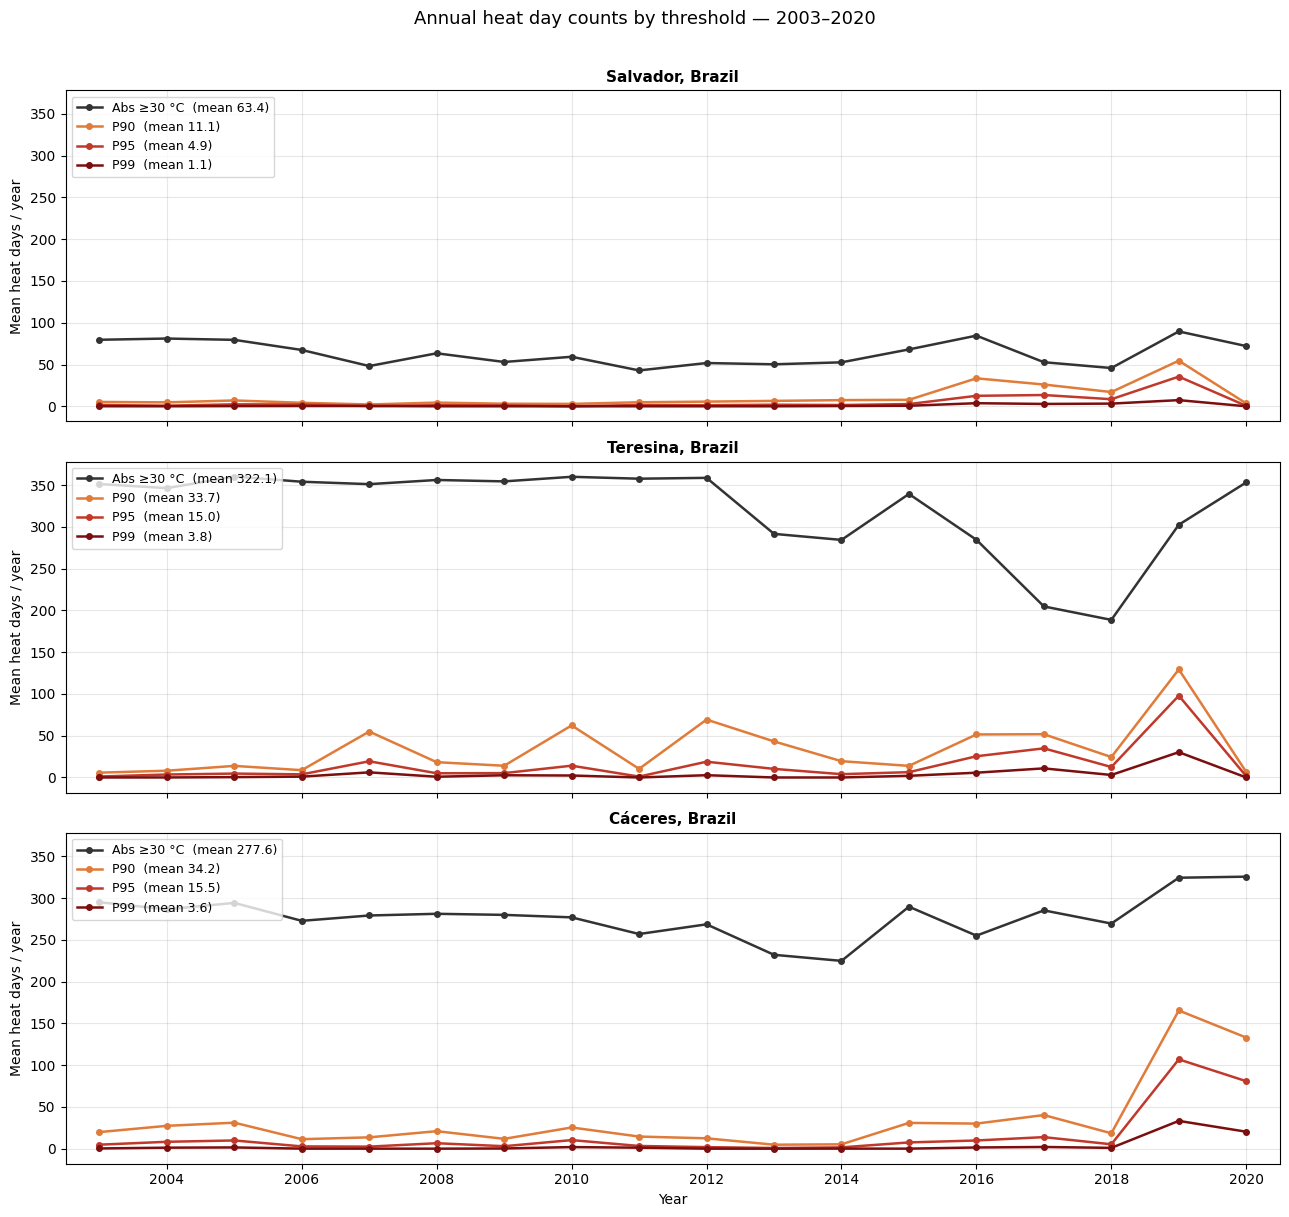

,Abs ≥30 °C,P90,P95,P99
City,,,,
"Salvador, Brazil",63.4,11.1,4.9,1.1
"Teresina, Brazil",322.1,33.7,15.0,3.8
"Cáceres, Brazil",277.6,34.2,15.5,3.6


In [17]:
fig, axes = plt.subplots(3, 1, figsize=(13, 12), sharex=True, sharey=True)
period_rows = []

for ax, c in zip(axes, CITY_KEYS):
    label      = CITIES[c]['label']
    period_row = {'City': label}

    abs_counts = [
        float((cities[c].sel(time=cities[c].time.dt.year == yr) >= ABS_THRESHOLD)
              .sum(dim='time').mean())
        for yr in ALL_YEARS
    ]
    mean_abs = float(np.mean(abs_counts))
    period_row[f'Abs ≥{ABS_THRESHOLD:.0f} °C'] = mean_abs
    ax.plot(ALL_YEARS, abs_counts, marker='o', markersize=4, linewidth=1.8,
            color=COLOURS[f'Abs ≥{ABS_THRESHOLD:.0f} °C'],
            label=f'Abs ≥{ABS_THRESHOLD:.0f} °C  (mean {mean_abs:.1f})')

    for p in TX90P_PERCENTILES:
        tx_counts = [
            float(tx_annual[c][p].isel(time=(tx_annual[c][p].time.dt.year == yr)).squeeze().mean())
            for yr in ALL_YEARS
        ]
        mean_tx = float(np.mean(tx_counts))
        period_row[f'P{p}'] = mean_tx
        ax.plot(ALL_YEARS, tx_counts, marker='o', markersize=4, linewidth=1.8,
                color=pct_colours[f'P{p}'],
                label=f'P{p}  (mean {mean_tx:.1f})')

    period_rows.append(period_row)
    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.set_ylabel('Mean heat days / year')
    ax.legend(fontsize=9, loc='upper left')
    ax.grid(True, alpha=0.3)
    ax.set_xlim(ALL_YEARS[0] - 0.5, ALL_YEARS[-1] + 0.5)
    ax.xaxis.set_major_locator(plt.MultipleLocator(2))

axes[-1].set_xlabel('Year')
fig.suptitle('Annual heat day counts by threshold — 2003–2020', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

period_df = pd.DataFrame(period_rows).set_index('City')
display(
    period_df.style
    .format('{:.1f}')
    .background_gradient(cmap='YlOrRd', axis=None, vmin=0)
    .set_caption('2003–2020 period averages — mean heat days per year (city-wide pixel average)')
    .set_table_styles(table_styles)
)

## Summary

Key outputs from this notebook:

1. **Threshold seasonality** — confirms the 5-day window produces genuine
   seasonal variation; the threshold tracks each city's annual temperature cycle.

2. **Tmax distribution + thresholds** — histograms showing where each
   calendar-day threshold sits relative to the observed distribution.

3. **Annual time series** — inter-annual variability across all four threshold
   framings (absolute + P90/P95/P99).

4. **Spatial maps** — neighbourhood choropleths comparing absolute vs P90
   calendar-day framings for the representative year.

5. **Quadrant plots** — identify neighbourhoods robustly high-burden under
   both framings, informing prioritisation decisions.

To change the analysis year or absolute threshold, edit `YEAR` or
`ABS_THRESHOLD` in the Setup section and re-run from that cell.